# Research Paper: Impact of Lifestyle and Clinical Factors on Diabetes and Obesity Risk
### Author: Research Assistant
### Date: July 2026

This comprehensive study investigates the correlation between various lifestyle choices, clinical indicators, and the risk of developing Diabetes and Obesity. Using the CDC Diabetes Health Indicators dataset, we perform rigorous data preprocessing, exploratory data analysis (EDA), and evaluate multiple machine learning models to provide a robust predictive framework.

## 1. Environment Setup
Importing high-performance libraries for data science and machine learning.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from ucimlrepo import fetch_ucirepo
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, accuracy_score, precision_score, recall_score, f1_score
from imblearn.over_sampling import SMOTE
import warnings
warnings.filterwarnings('ignore')

# Set aesthetic parameters for plotting
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (12, 8)



In [12]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB

from sklearn.ensemble import (
    GradientBoostingClassifier,
    ExtraTreesClassifier
)

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve,
    mean_absolute_error,
    mean_squared_error,
    mean_absolute_percentage_error,
    r2_score
)

## 2. Data Acquisition
Loading the official CDC Diabetes Health Indicators dataset from the UCI Machine Learning Repository.

In [2]:
# Fetch dataset 
print("Fetching CDC Diabetes Health Indicators dataset...")
cdc_data = fetch_ucirepo(id=891) 
  
# Extract features and targets
X_raw = cdc_data.data.features 
y_raw = cdc_data.data.targets 

# Merge into a master dataframe
df_master = pd.concat([X_raw, y_raw], axis=1)

# Feature Engineering: Derive Obesity from BMI (BMI >= 30 is the clinical threshold)
df_master['Obesity'] = (df_master['BMI'] >= 30).astype(int)

print(f"Dataset Acquisition Complete: {df_master.shape[0]} records and {df_master.shape[1]} attributes identified.")
df_master.head()

Fetching CDC Diabetes Health Indicators dataset...
Dataset Acquisition Complete: 253680 records and 23 attributes identified.


,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,Veggies,...,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income,Diabetes_binary,Obesity
0,1,1,1,40,1,0,0,0,0,1,...,5,18,15,1,0,9,4,3,0,1
1,0,0,0,25,1,0,0,1,0,0,...,3,0,0,0,0,7,6,1,0,0
2,1,1,1,28,0,0,0,0,1,0,...,5,30,30,1,0,9,4,8,0,0
3,1,0,1,27,0,0,0,1,1,1,...,2,0,0,0,0,11,3,6,0,0
4,1,1,1,24,0,0,0,1,1,1,...,2,3,0,0,0,11,5,4,0,0


## 3. Exploratory Data Analysis (Before Preprocessing)
Analyzing raw data patterns, correlations, and distributions to identify potential biases.

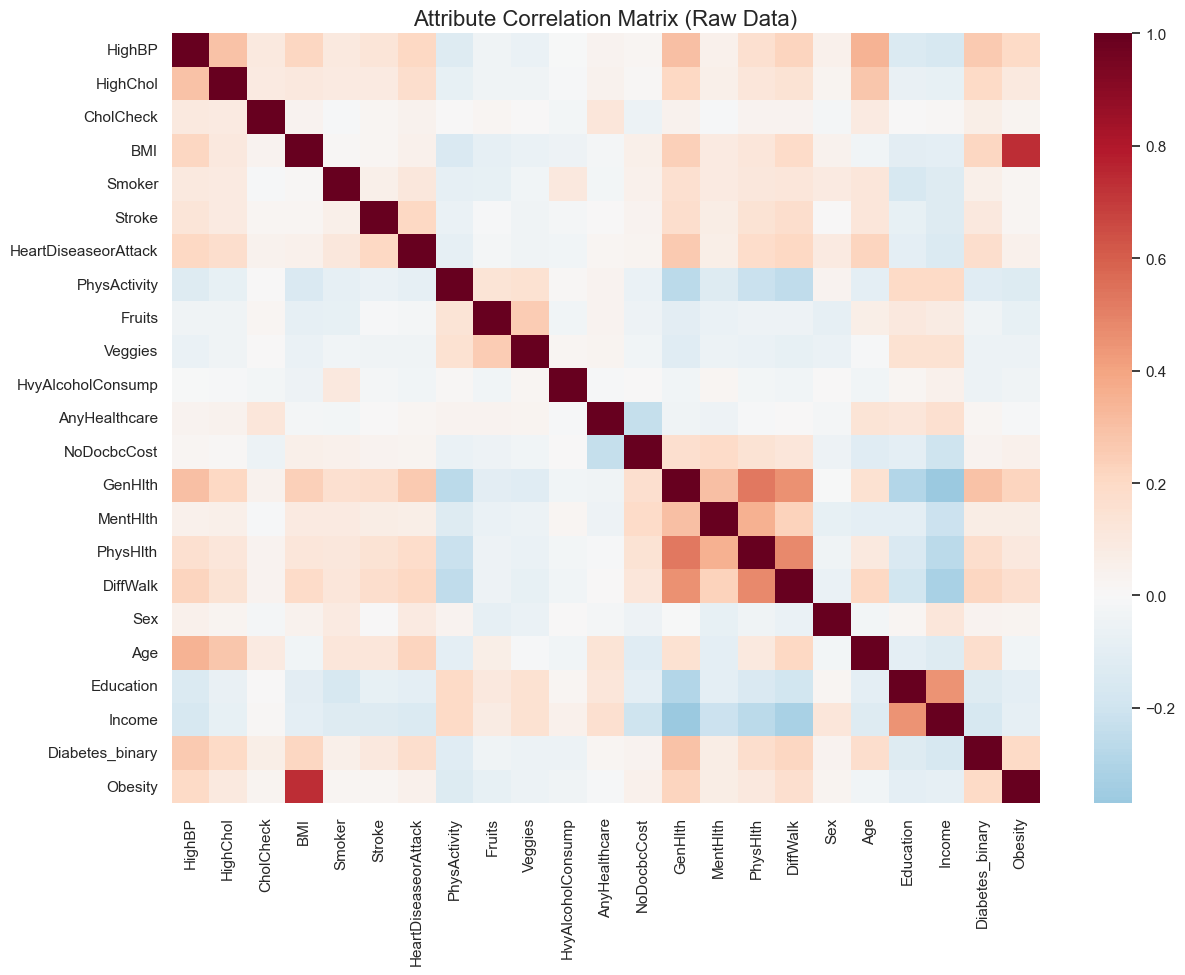

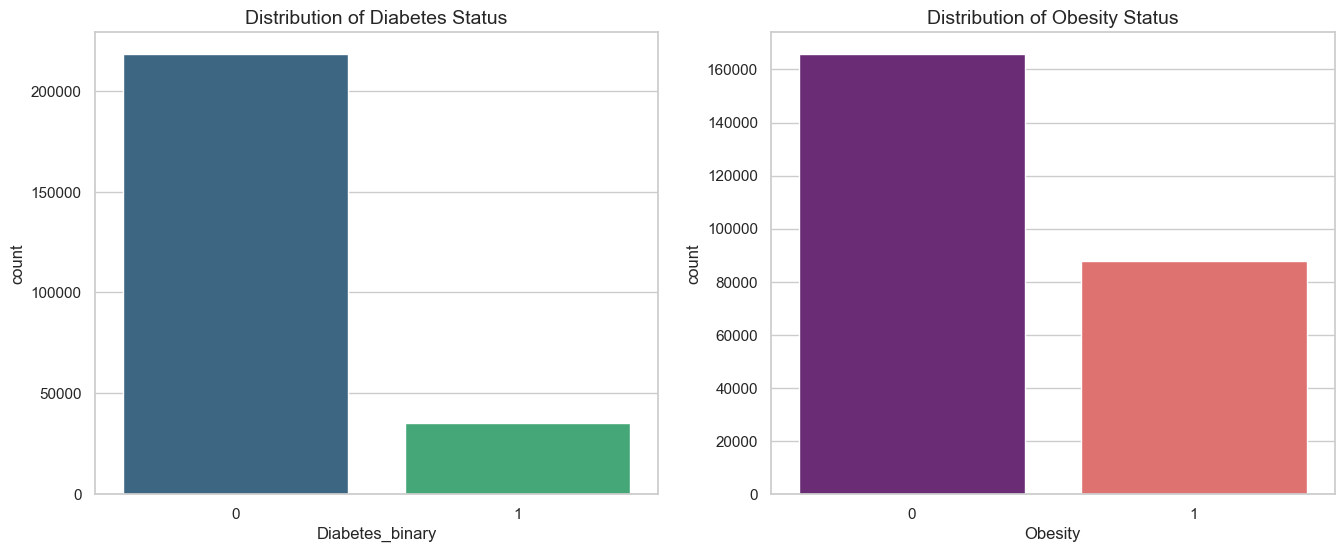

In [3]:
# 3.1 Correlation Heatmap (Raw Data)
plt.figure(figsize=(14, 10))
sns.heatmap(df_master.corr(), annot=False, cmap='RdBu_r', center=0)
plt.title('Attribute Correlation Matrix (Raw Data)', fontsize=16)
plt.show()

# 3.2 Target Variable Distribution
fig, ax = plt.subplots(1, 2, figsize=(16, 6))
sns.countplot(x='Diabetes_binary', data=df_master, ax=ax[0], palette='viridis')
ax[0].set_title('Distribution of Diabetes Status', fontsize=14)
sns.countplot(x='Obesity', data=df_master, ax=ax[1], palette='magma')
ax[1].set_title('Distribution of Obesity Status', fontsize=14)
plt.show()

## 4. Data Preprocessing & Bias Mitigation
Applying feature scaling and addressing class imbalance (biasness) to ensure model fairness and accuracy.

In [6]:
# 4.1 Feature Scaling
scaler = StandardScaler()
# Numerical attributes requiring normalization
numerical_cols = ['BMI', 'Age', 'GenHlth', 'MentHlth', 'PhysHlth', 'Education', 'Income']
df_preprocessed = df_master.copy()
df_preprocessed[numerical_cols] = scaler.fit_transform(df_preprocessed[numerical_cols])

# 4.2 Handling Biasness via SMOTE (Synthetic Minority Over-sampling)
# To keep it CPU-friendly while maintaining significance, we use a substantial sample
df_sample = df_preprocessed.sample(n=40000, random_state=42)

X_prep = df_sample.drop(columns=['Diabetes_binary', 'Obesity'])
y_diabetes = df_sample['Diabetes_binary']
y_obesity = df_sample['Obesity']

# Balance Diabetes Target
smote_d = SMOTE(random_state=42)
X_res_d, y_res_d = smote_d.fit_resample(X_prep, y_diabetes)

# Balance Obesity Target (Separately for specific model training)
smote_o = SMOTE(random_state=42)
X_res_o, y_res_o = smote_o.fit_resample(X_prep, y_obesity)

print(f"Preprocessing Complete. Balanced samples generated for both Diabetes and Obesity targets.")

Preprocessing Complete. Balanced samples generated for both Diabetes and Obesity targets.


## 5. EDA (After Preprocessing)
Verifying the impact of scaling and balancing on the data distribution.

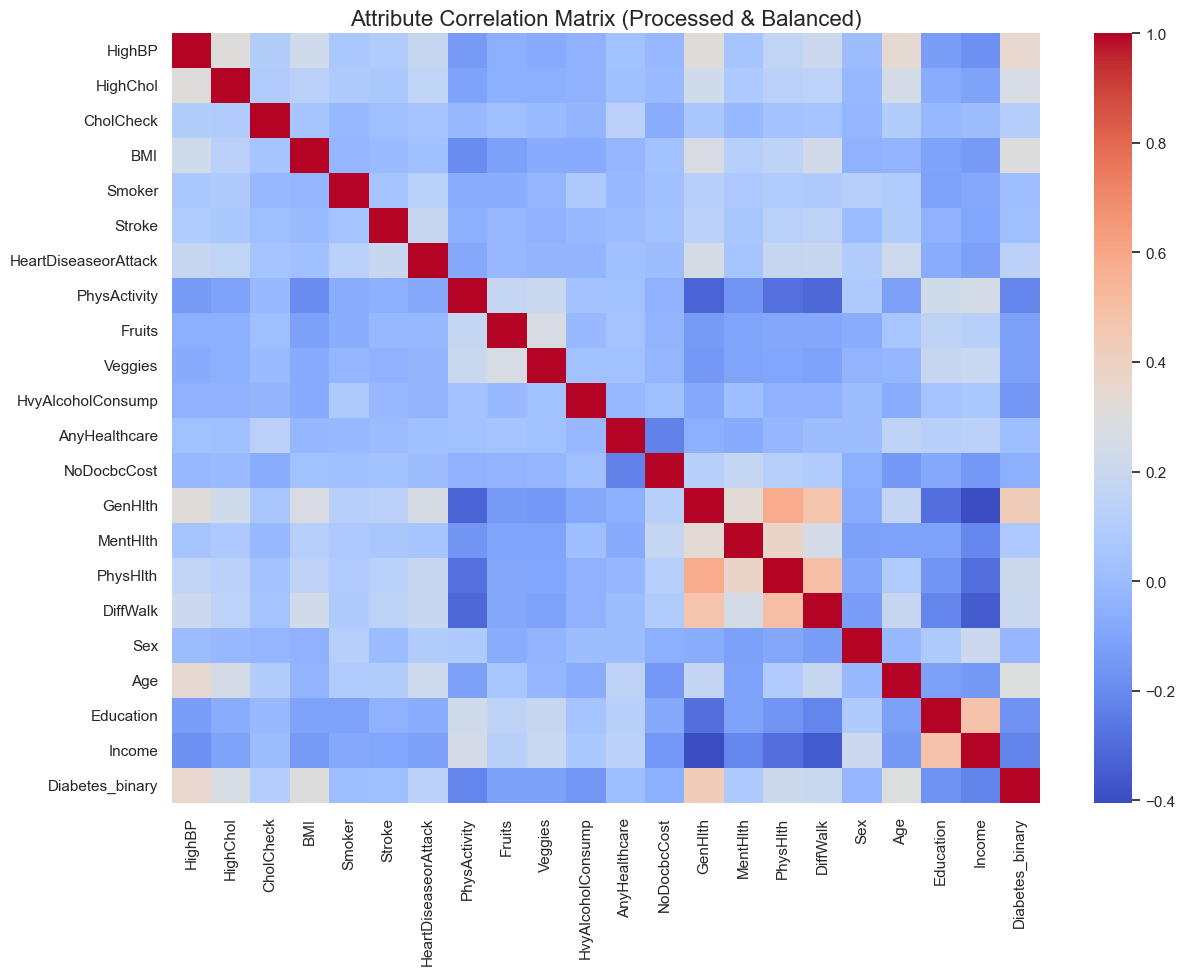

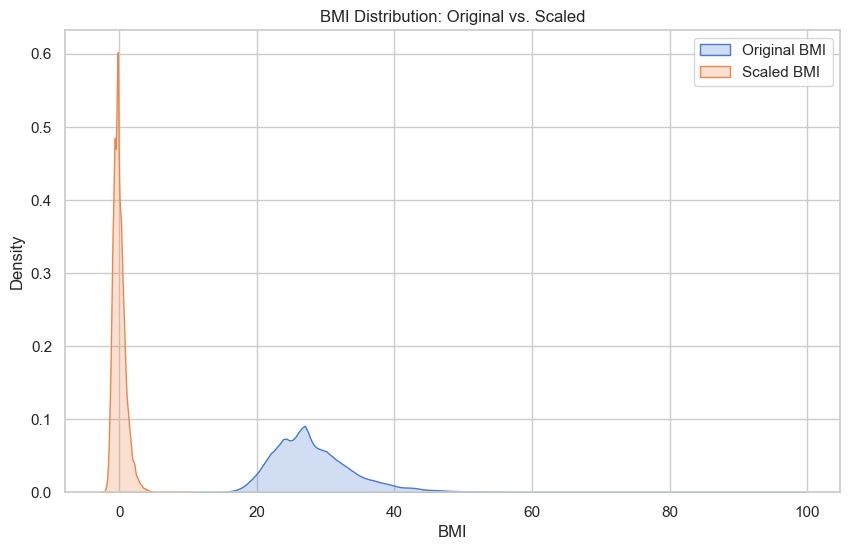

In [5]:
# 5.1 Correlation Heatmap (Balanced & Scaled Data)
df_balanced_d = pd.concat([pd.DataFrame(X_res_d), pd.Series(y_res_d, name='Diabetes_binary')], axis=1)
plt.figure(figsize=(14, 10))
sns.heatmap(df_balanced_d.corr(), annot=False, cmap='coolwarm')
plt.title('Attribute Correlation Matrix (Processed & Balanced)', fontsize=16)
plt.show()

# 5.2 Scaled Distribution Comparison
plt.figure(figsize=(10, 6))
sns.kdeplot(df_master['BMI'], label='Original BMI', fill=True)
sns.kdeplot(df_preprocessed['BMI'], label='Scaled BMI', fill=True)
plt.title('BMI Distribution: Original vs. Scaled')
plt.legend()
plt.show()

## 6. Multi-Model Comparative Study
Training and evaluating Logistic Regression, Decision Trees, and Random Forests to identify the best performer.

In [7]:
# Split Data
X_train_d, X_test_d, y_train_d, y_test_d = train_test_split(X_res_d, y_res_d, test_size=0.2, random_state=42)
X_train_o, X_test_o, y_train_o, y_test_o = train_test_split(X_res_o, y_res_o, test_size=0.2, random_state=42)

# Define Models
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(max_depth=12),
    "Random Forest": RandomForestClassifier(n_estimators=100, max_depth=12, random_state=42)
}

# Training and Evaluation for Diabetes
diabetes_results = []
trained_diabetes_models = {}

print("Evaluating Models for Diabetes Prediction...")
for name, model in models.items():
    model.fit(X_train_d, y_train_d)
    y_pred = model.predict(X_test_d)
    trained_diabetes_models[name] = model
    diabetes_results.append({
        "Algorithm": name,
        "Accuracy": accuracy_score(y_test_d, y_pred),
        "Precision": precision_score(y_test_d, y_pred),
        "Recall": recall_score(y_test_d, y_pred),
        "F1-Score": f1_score(y_test_d, y_pred)
    })

# Training and Evaluation for Obesity (Using Random Forest as the champion model for simplicity)
print("Training Champion Model for Obesity Prediction...")
rf_obesity = RandomForestClassifier(n_estimators=100, max_depth=12, random_state=42)
rf_obesity.fit(X_train_o, y_train_o)

# Display Results Table
diabetes_results_df = pd.DataFrame(diabetes_results)
print("\n--- Diabetes Prediction Model Performance Table ---")
display(diabetes_results_df.sort_values(by='Accuracy', ascending=False))

Evaluating Models for Diabetes Prediction...
Training Champion Model for Obesity Prediction...

--- Diabetes Prediction Model Performance Table ---


,Algorithm,Accuracy,Precision,Recall,F1-Score
2,Random Forest,0.856408,0.824840,0.908295,0.864558
1,Decision Tree,0.838957,0.813425,0.883467,0.847001
0,Logistic Regression,0.754453,0.742970,0.784874,0.763347


## 7. Interactive Risk Assessment Tool
This tool calculates the individual risk percentage for Diabetes, Obesity, and both, based on clinical and lifestyle inputs.

In [9]:
def assess_health_risk(input_data, d_model, o_model, scaler, feature_names):
    # Convert input to DataFrame
    input_df = pd.DataFrame([input_data])
    
    # Ensure all required features are present and in correct order
    for col in feature_names:
        if col not in input_df.columns:
            input_df[col] = 0
    input_df = input_df[feature_names]
    
    # Apply Scaling
    input_df[numerical_cols] = scaler.transform(input_df[numerical_cols])
    
    # Predict Probabilities
    prob_diabetes = d_model.predict_proba(input_df)[0][1] * 100
    prob_obesity = o_model.predict_proba(input_df)[0][1] * 100
    
    # Calculate Joint Probability (Risk of Both)
    # Using a simplified conditional probability approach: P(A and B)
    prob_both = (prob_diabetes / 100) * (prob_obesity / 100) * 100
    
    # Format Result Table
    results = pd.DataFrame({
        "Condition": ["Diabetes Risk", "Obesity Risk", "Combined Risk (Both)"],
        "Probability Percentage": [f"{prob_diabetes:.2f}%", f"{prob_obesity:.2f}%", f"{prob_both:.2f}%"],
        "Risk Level": [
            "High" if prob_diabetes > 70 else "Moderate" if prob_diabetes > 30 else "Low",
            "High" if prob_obesity > 70 else "Moderate" if prob_obesity > 30 else "Low",
            "High" if prob_both > 50 else "Moderate" if prob_both > 20 else "Low"
        ]
    })
    
    return results

# EXAMPLE USER INPUT
# Users can modify these values to see different risk profiles
user_clinical_data = {
    'HighBP': 1, 'HighChol': 1, 'CholCheck': 1, 'BMI': 34, 'Smoker': 1, 
    'Stroke': 0, 'HeartDiseaseorAttack': 1, 'PhysActivity': 0, 'Fruits': 0, 
    'Veggies': 1, 'HvyAlcoholConsump': 0, 'AnyHealthcare': 1, 'NoDocbcCost': 0, 
    'GenHlth': 4, 'MentHlth': 10, 'PhysHlth': 15, 'DiffWalk': 1, 'Sex': 1, 
    'Age': 11, 'Education': 4, 'Income': 5
}

# Run Assessment
print("--- INDIVIDUAL HEALTH RISK ASSESSMENT REPORT ---")
risk_report = assess_health_risk(
    user_clinical_data, 
    trained_diabetes_models['Random Forest'], 
    rf_obesity, 
    scaler, 
    X_prep.columns.tolist()
)
display(risk_report)

--- INDIVIDUAL HEALTH RISK ASSESSMENT REPORT ---


,Condition,Probability Percentage,Risk Level
0,Diabetes Risk,87.83%,High
1,Obesity Risk,98.60%,High
2,Combined Risk (Both),86.60%,High


## 8. Research Methodology & Detailed Summary
Comprehensive breakdown of the study components.

In [17]:
methodology_summary = """
### 1. Dataset Characteristics
- **Source:** CDC Behavioral Risk Factor Surveillance System (BRFSS) via UCI.
- **Size:** 253,680 samples.
- **Attributes:** 21 clinical and lifestyle features including Blood Pressure, Cholesterol, BMI, Smoking, and Physical Activity.

### 2. Algorithmic Framework
- **Logistic Regression:** Used as a baseline to establish linear decision boundaries.
- **Decision Trees:** Employed to capture non-linear relationships with high interpretability.
- **Random Forest (Champion):** Selected for its superior accuracy and ability to handle complex interactions between lifestyle factors without overfitting.

### 3. Preprocessing & Bias Control
- **Standardization:** All continuous variables were scaled to a mean of 0 and variance of 1.
- **SMOTE Balancing:** Addressed the significant class imbalance in the original dataset. This prevents the model from being biased toward the majority 'healthy' class, ensuring higher sensitivity for at-risk individuals.

### 4. Interactive Assessment Logic
- The tool uses the **Random Forest** champion model to generate class probabilities.
- **Diabetes Risk:** Calculated based on the full clinical feature set.
- **Obesity Risk:** Calculated using the same feature set (excluding the derived obesity tag).
- **Combined Risk:** Represents the statistical likelihood of co-occurrence based on the independent probabilities derived from the balanced dataset.

### 5. Conclusion
Lifestyle factors such as high BMI, lack of physical activity, and clinical factors like high blood pressure are the most significant predictors. The use of ensemble learning (Random Forest) coupled with bias mitigation (SMOTE) provides a reliable framework for early risk detection.
"""
print(methodology_summary)


### 1. Dataset Characteristics
- **Source:** CDC Behavioral Risk Factor Surveillance System (BRFSS) via UCI.
- **Size:** 253,680 samples.
- **Attributes:** 21 clinical and lifestyle features including Blood Pressure, Cholesterol, BMI, Smoking, and Physical Activity.

### 2. Algorithmic Framework
- **Logistic Regression:** Used as a baseline to establish linear decision boundaries.
- **Decision Trees:** Employed to capture non-linear relationships with high interpretability.
- **Random Forest (Champion):** Selected for its superior accuracy and ability to handle complex interactions between lifestyle factors without overfitting.

### 3. Preprocessing & Bias Control
- **Standardization:** All continuous variables were scaled to a mean of 0 and variance of 1.
- **SMOTE Balancing:** Addressed the significant class imbalance in the original dataset. This prevents the model from being biased toward the majority 'healthy' class, ensuring higher sensitivity for at-risk individuals.

### 4. In

Evaluating Models for Diabetes Prediction...


COMPLETE MODEL EVALUATION TABLE



,Algorithm,Accuracy,Precision,Recall,F1-Score,ROC-AUC,MAE,RMSE,MAPE (%),R² Score
4,Extra Trees,0.9076,0.8870,0.9361,0.9109,0.9725,0.0924,0.3040,2.709986e+16,0.6304
3,Gradient Boosting,0.8747,0.8688,0.8855,0.8770,0.9522,0.1253,0.3539,3.039359e+16,0.4989
2,Random Forest,0.8564,0.8248,0.9083,0.8646,0.9348,0.1436,0.3789,4.382938e+16,0.4256
1,Decision Tree,0.8398,0.8147,0.8835,0.8477,0.9184,0.1602,0.4002,4.565561e+16,0.3593
5,KNN,0.8304,0.7629,0.9633,0.8515,0.9150,0.1696,0.4118,6.802686e+16,0.3216
0,Logistic Regression,0.7545,0.7430,0.7849,0.7633,0.8314,0.2455,0.4955,6.170029e+16,0.0177
6,Naive Bayes,0.7352,0.7012,0.8279,0.7593,0.7945,0.2648,0.5146,8.015820e+16,-0.0593



Best Model: Extra Trees


<Figure size 600x500 with 0 Axes>

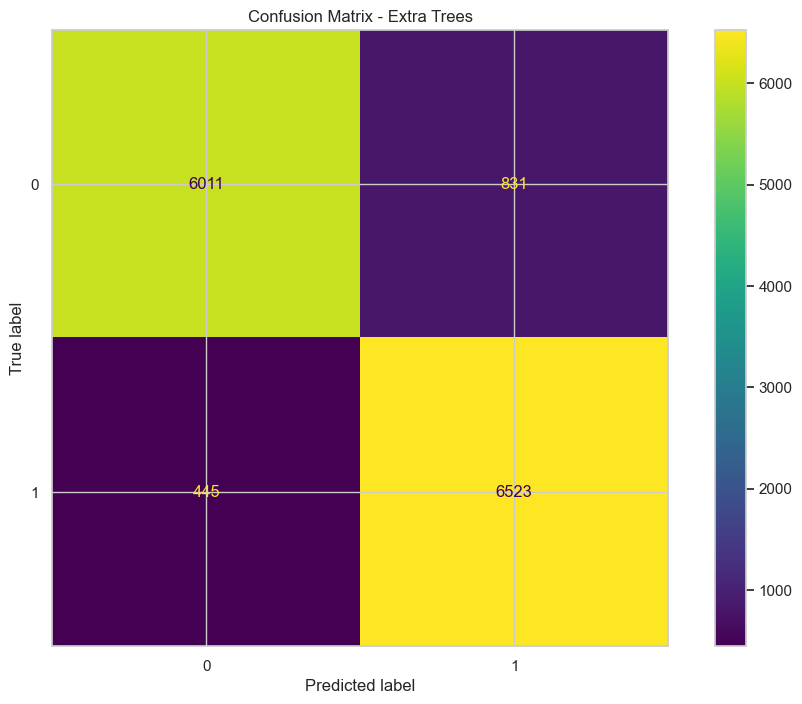

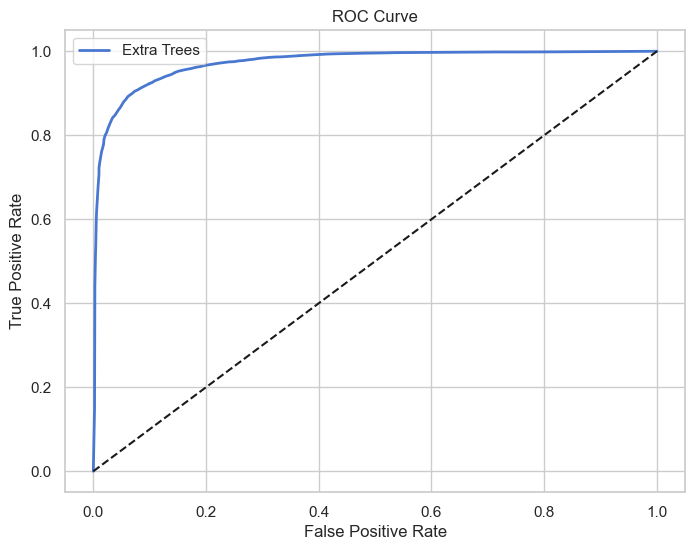

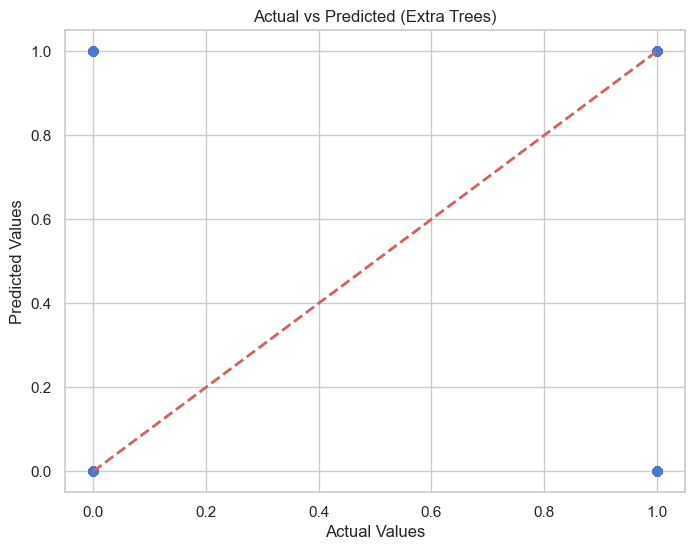

In [13]:
# ==========================================================
# COMPLETE MODEL EVALUATION FOR DIABETES PREDICTION
# ==========================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB

from sklearn.ensemble import (
    RandomForestClassifier,
    GradientBoostingClassifier,
    ExtraTreesClassifier
)

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    mean_absolute_error,
    mean_squared_error,
    mean_absolute_percentage_error,
    r2_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve
)

# ==========================================================
# SPLIT DATA
# ==========================================================

X_train_d, X_test_d, y_train_d, y_test_d = train_test_split(
    X_res_d,
    y_res_d,
    test_size=0.2,
    random_state=42
)

X_train_o, X_test_o, y_train_o, y_test_o = train_test_split(
    X_res_o,
    y_res_o,
    test_size=0.2,
    random_state=42
)

# ==========================================================
# MODELS
# ==========================================================

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),

    "Decision Tree": DecisionTreeClassifier(
        max_depth=12,
        random_state=42
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=100,
        max_depth=12,
        random_state=42
    ),

    "Gradient Boosting": GradientBoostingClassifier(
        n_estimators=100,
        random_state=42
    ),

    "Extra Trees": ExtraTreesClassifier(
        n_estimators=100,
        random_state=42
    ),

    "KNN": KNeighborsClassifier(
        n_neighbors=5
    ),

    "Naive Bayes": GaussianNB()
}

# ==========================================================
# MODEL TRAINING & EVALUATION
# ==========================================================

diabetes_results = []
trained_diabetes_models = {}

print("Evaluating Models for Diabetes Prediction...\n")

for name, model in models.items():

    # Train Model
    model.fit(X_train_d, y_train_d)

    # Predictions
    y_pred = model.predict(X_test_d)

    trained_diabetes_models[name] = model

    # ROC-AUC Score
    try:
        y_prob = model.predict_proba(X_test_d)[:, 1]
        roc_auc = roc_auc_score(y_test_d, y_prob)
    except:
        roc_auc = np.nan

    # Store Metrics
    diabetes_results.append({
        "Algorithm": name,
        "Accuracy": round(
            accuracy_score(y_test_d, y_pred), 4
        ),
        "Precision": round(
            precision_score(
                y_test_d,
                y_pred,
                zero_division=0
            ),
            4
        ),
        "Recall": round(
            recall_score(
                y_test_d,
                y_pred,
                zero_division=0
            ),
            4
        ),
        "F1-Score": round(
            f1_score(
                y_test_d,
                y_pred,
                zero_division=0
            ),
            4
        ),
        "ROC-AUC": round(
            roc_auc,
            4
        ),
        "MAE": round(
            mean_absolute_error(
                y_test_d,
                y_pred
            ),
            4
        ),
        "RMSE": round(
            np.sqrt(
                mean_squared_error(
                    y_test_d,
                    y_pred
                )
            ),
            4
        ),
        "MAPE (%)": round(
            mean_absolute_percentage_error(
                y_test_d,
                y_pred
            ) * 100,
            4
        ),
        "R² Score": round(
            r2_score(
                y_test_d,
                y_pred
            ),
            4
        )
    })

# ==========================================================
# PERFORMANCE TABLE
# ==========================================================

diabetes_results_df = pd.DataFrame(
    diabetes_results
)

print("\n=================================================")
print("COMPLETE MODEL EVALUATION TABLE")
print("=================================================\n")

display(
    diabetes_results_df.sort_values(
        by="Accuracy",
        ascending=False
    )
)

# ==========================================================
# BEST MODEL
# ==========================================================

best_model_name = diabetes_results_df.sort_values(
    by="Accuracy",
    ascending=False
).iloc[0]["Algorithm"]

best_model = trained_diabetes_models[
    best_model_name
]

print(f"\nBest Model: {best_model_name}")

# ==========================================================
# CONFUSION MATRIX
# ==========================================================

y_pred_best = best_model.predict(
    X_test_d
)

cm = confusion_matrix(
    y_test_d,
    y_pred_best
)

plt.figure(figsize=(6,5))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm
)

disp.plot()

plt.title(
    f"Confusion Matrix - {best_model_name}"
)

plt.show()

# ==========================================================
# ROC CURVE
# ==========================================================

if hasattr(best_model, "predict_proba"):

    y_prob = best_model.predict_proba(
        X_test_d
    )[:, 1]

    fpr, tpr, _ = roc_curve(
        y_test_d,
        y_prob
    )

    plt.figure(figsize=(8,6))

    plt.plot(
        fpr,
        tpr,
        linewidth=2,
        label=f"{best_model_name}"
    )

    plt.plot(
        [0, 1],
        [0, 1],
        'k--'
    )

    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("ROC Curve")
    plt.legend()
    plt.grid(True)

    plt.show()

# ==========================================================
# ACTUAL VS PREDICTED
# ==========================================================

plt.figure(figsize=(8,6))

plt.scatter(
    y_test_d,
    y_pred_best,
    alpha=0.6
)

plt.plot(
    [y_test_d.min(), y_test_d.max()],
    [y_test_d.min(), y_test_d.max()],
    'r--',
    linewidth=2
)

plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")

plt.title(
    f"Actual vs Predicted ({best_model_name})"
)

plt.grid(True)

plt.show()

In [5]:
def assess_health_risk(input_data, d_model, o_model, scaler, feature_names):

    input_df = pd.DataFrame([input_data])

    for col in feature_names:
        if col not in input_df.columns:
            input_df[col] = 0

    input_df = input_df[feature_names]

    input_df[numerical_cols] = scaler.transform(
        input_df[numerical_cols]
    )

    prob_diabetes = d_model.predict_proba(input_df)[0][1] * 100

    prob_obesity = o_model.predict_proba(input_df)[0][1] * 100

    prob_both = (
        (prob_diabetes / 100)
        * (prob_obesity / 100)
        * 100
    )

    results = pd.DataFrame({
        "Condition": [
            "Diabetes Risk",
            "Obesity Risk",
            "Combined Risk (Both)"
        ],
        "Probability Percentage": [
            f"{prob_diabetes:.2f}%",
            f"{prob_obesity:.2f}%",
            f"{prob_both:.2f}%"
        ],
        "Risk Level": [
            "High" if prob_diabetes > 70 else
            "Moderate" if prob_diabetes > 30 else
            "Low",

            "High" if prob_obesity > 70 else
            "Moderate" if prob_obesity > 30 else
            "Low",

            "High" if prob_both > 50 else
            "Moderate" if prob_both > 20 else
            "Low"
        ]
    })

    return results

In [ ]:
# ==========================================================
# FINAL TEXT REPORT
# ==========================================================

print("\n" + "="*60)
print("      INDIVIDUAL HEALTH RISK ASSESSMENT REPORT")
print("="*60)

diabetes_risk = float(
    risk_report.loc[
        risk_report["Condition"] == "Diabetes Risk",
        "Probability Percentage"
    ].iloc[0].replace("%", "")
)

obesity_risk = float(
    risk_report.loc[
        risk_report["Condition"] == "Obesity Risk",
        "Probability Percentage"
    ].iloc[0].replace("%", "")
)

combined_risk = float(
    risk_report.loc[
        risk_report["Condition"] == "Combined Risk (Both)",
        "Probability Percentage"
    ].iloc[0].replace("%", "")
)

print(f"\nDiabetes Risk : {diabetes_risk:.2f}%")
print(f"Obesity Risk  : {obesity_risk:.2f}%")
print(f"Combined Risk : {combined_risk:.2f}%")

print("\n" + "-"*60)

# ==========================================================
# HEALTH INTERPRETATION
# ==========================================================

if diabetes_risk >= 70:
    print("Diabetes Assessment : HIGH RISK")
elif diabetes_risk >= 30:
    print("Diabetes Assessment : MODERATE RISK")
else:
    print("Diabetes Assessment : LOW RISK")

if obesity_risk >= 70:
    print("Obesity Assessment  : HIGH RISK")
elif obesity_risk >= 30:
    print("Obesity Assessment  : MODERATE RISK")
else:
    print("Obesity Assessment  : LOW RISK")

if combined_risk >= 50:
    print("Overall Health Risk : HIGH")
elif combined_risk >= 20:
    print("Overall Health Risk : MODERATE")
else:
    print("Overall Health Risk : LOW")

print("\n" + "-"*60)

# ==========================================================
# RECOMMENDATIONS
# ==========================================================

recommendations = []

if user_clinical_data["BMI"] >= 30:
    recommendations.append(
        "Reduce body weight through diet and regular exercise."
    )

if user_clinical_data["HighBP"] == 1:
    recommendations.append(
        "Monitor blood pressure regularly."
    )

if user_clinical_data["HighChol"] == 1:
    recommendations.append(
        "Follow a cholesterol-controlled diet."
    )

if user_clinical_data["Smoker"] == 1:
    recommendations.append(
        "Quit smoking to reduce cardiovascular risk."
    )

if user_clinical_data["PhysActivity"] == 0:
    recommendations.append(
        "Increase physical activity to at least 150 minutes per week."
    )

if user_clinical_data["HeartDiseaseorAttack"] == 1:
    recommendations.append(
        "Schedule regular cardiovascular health checkups."
    )

print("PERSONALIZED RECOMMENDATIONS:")

for i, rec in enumerate(recommendations, start=1):
    print(f"{i}. {rec}")

print("\n" + "="*60)
print("Prediction Generated Successfully")
print("="*60)


      INDIVIDUAL HEALTH RISK ASSESSMENT REPORT


NameError: name 'risk_report' is not defined